In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data'
TODAY    = pd.Timestamp.today().normalize()

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

COLORS = {
    'normal':   '#3b82f6',
    'anomaly':  '#ef4444',
    'band':     '#93c5fd',
    'forecast': '#f97316',
}

In [5]:
sends     = pd.read_csv(DATA_DIR / 'email_sends.csv',    parse_dates=['send_date'])
campaigns = pd.read_csv(DATA_DIR / 'email_campaigns.csv', parse_dates=['send_date'])
subs      = pd.read_csv(DATA_DIR / 'subscriptions.csv',  parse_dates=['signup_date','churn_date'])
events    = pd.read_csv(DATA_DIR / 'product_events.csv', parse_dates=['event_date'])

#  Weekly email metrics
weekly_email = (
    sends
    .assign(week=sends['send_date'].dt.to_period('W').dt.start_time)
    .groupby('week')
    .agg(
        total_sent  = ('send_id',  'count'),
        total_open  = ('opened',   'sum'),
        total_reply = ('replied',  'sum'),
        total_click = ('clicked',  'sum'),
    )
    .reset_index()
)
weekly_email['open_rate']  = weekly_email['total_open']  / weekly_email['total_sent']
weekly_email['reply_rate'] = weekly_email['total_reply'] / weekly_email['total_sent']
weekly_email['click_rate'] = weekly_email['total_click'] / weekly_email['total_sent']

# Monthly MRR 
monthly_new = (
    subs.assign(month=subs['signup_date'].dt.to_period('M').dt.start_time)
    .groupby('month')['mrr'].sum()
    .reset_index(name='new_mrr')
)

monthly_churned = (
    subs[subs['status'] == 'churned']
    .assign(month=subs.loc[subs['status']=='churned', 'churn_date']
            .dt.to_period('M').dt.start_time)
    .groupby('month')['mrr'].sum()
    .reset_index(name='churned_mrr')
)

monthly_mrr = monthly_new.merge(monthly_churned, on='month', how='left').fillna(0)
monthly_mrr['net_mrr']        = monthly_mrr['new_mrr'] - monthly_mrr['churned_mrr']
monthly_mrr['cumulative_mrr'] = monthly_mrr['net_mrr'].cumsum()
monthly_mrr = monthly_mrr[monthly_mrr['month'] < TODAY.to_period('M').to_timestamp()]

# Weekly Active Users 
weekly_wau = (
    events
    .assign(week=events['event_date'].dt.to_period('W').dt.start_time)
    .groupby('week')['user_id'].nunique()
    .reset_index(name='wau')
)

weekly_wau = weekly_wau[
    weekly_wau['week'] < TODAY - pd.Timedelta(days=TODAY.weekday())
]

# Minimal summary
print(
    f"MRR: ${monthly_mrr['cumulative_mrr'].iloc[-1]:,.0f} | "
    f"WAU: {weekly_wau['wau'].iloc[-1]:,} | "
    f"Open: {weekly_email['open_rate'].mean():.1%} | "
    f"Reply: {weekly_email['reply_rate'].mean():.1%}"
)

MRR: $100,719 | WAU: 267 | Open: 32.9% | Reply: 0.9%


Anomalies detected: 0
Empty DataFrame
Columns: [week, reply_rate, rolling_mean, z_score, direction]
Index: []


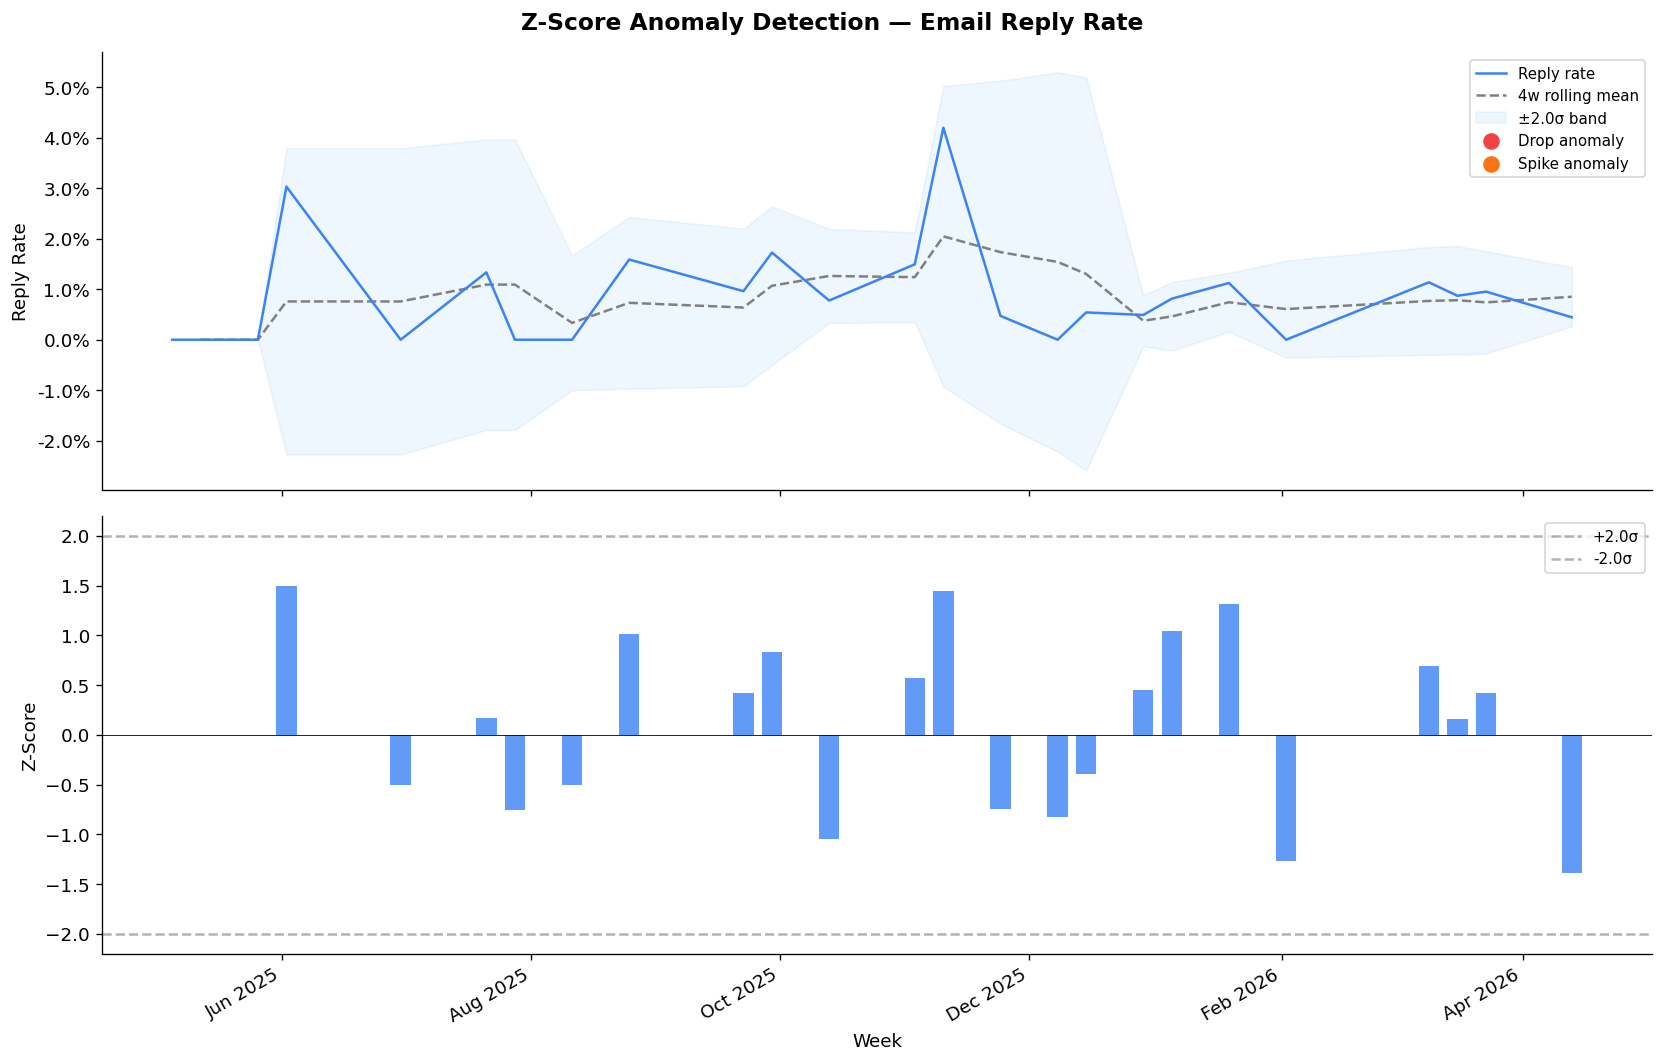

In [6]:
# Z-score anomaly detection 

WINDOW    = 4    
THRESHOLD = 2.0    

df = weekly_email.copy().sort_values('week').reset_index(drop=True)

df['rolling_mean'] = df['reply_rate'].rolling(WINDOW, min_periods=2).mean()
df['rolling_std']  = df['reply_rate'].rolling(WINDOW, min_periods=2).std()
df['z_score']      = (
    (df['reply_rate'] - df['rolling_mean']) /
    df['rolling_std'].replace(0, np.nan)
).round(3)
df['is_anomaly']   = df['z_score'].abs() > THRESHOLD
df['direction']    = np.where(df['z_score'] < -THRESHOLD, 'drop',
                    np.where(df['z_score'] >  THRESHOLD, 'spike', 'normal'))

anomalies = df[df['is_anomaly']]
print(f"Anomalies detected: {len(anomalies)}")
print(anomalies[['week','reply_rate','rolling_mean','z_score','direction']].to_string(index=False))

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Z-Score Anomaly Detection — Email Reply Rate', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(df['week'], df['reply_rate'],  color=COLORS['normal'], lw=1.5, label='Reply rate', zorder=3)
ax.plot(df['week'], df['rolling_mean'], color='gray', lw=1.5, linestyle='--', label=f'{WINDOW}w rolling mean')
ax.fill_between(
    df['week'],
    df['rolling_mean'] - THRESHOLD * df['rolling_std'],
    df['rolling_mean'] + THRESHOLD * df['rolling_std'],
    alpha=0.15, color=COLORS['band'], label=f'±{THRESHOLD}σ band'
)
# Mark anomalies
drops  = df[df['direction'] == 'drop']
spikes = df[df['direction'] == 'spike']
ax.scatter(drops['week'],  drops['reply_rate'],  color=COLORS['anomaly'], s=80, zorder=5, label='Drop anomaly')
ax.scatter(spikes['week'], spikes['reply_rate'], color=COLORS['forecast'], s=80, zorder=5, label='Spike anomaly')
ax.set_ylabel('Reply Rate')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

# Bottom: z-score
ax = axes[1]
ax.bar(df['week'], df['z_score'],
       color=[COLORS['anomaly'] if a else COLORS['normal'] for a in df['is_anomaly']],
       width=5, alpha=0.8)
ax.axhline( THRESHOLD, color='gray', linestyle='--', alpha=0.6, label=f'+{THRESHOLD}σ')
ax.axhline(-THRESHOLD, color='gray', linestyle='--', alpha=0.6, label=f'-{THRESHOLD}σ')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Z-Score')
ax.set_xlabel('Week')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

MRR anomalies: 2
     month  net_mrr
2025-12-01  13213.0
2026-03-01  18347.0


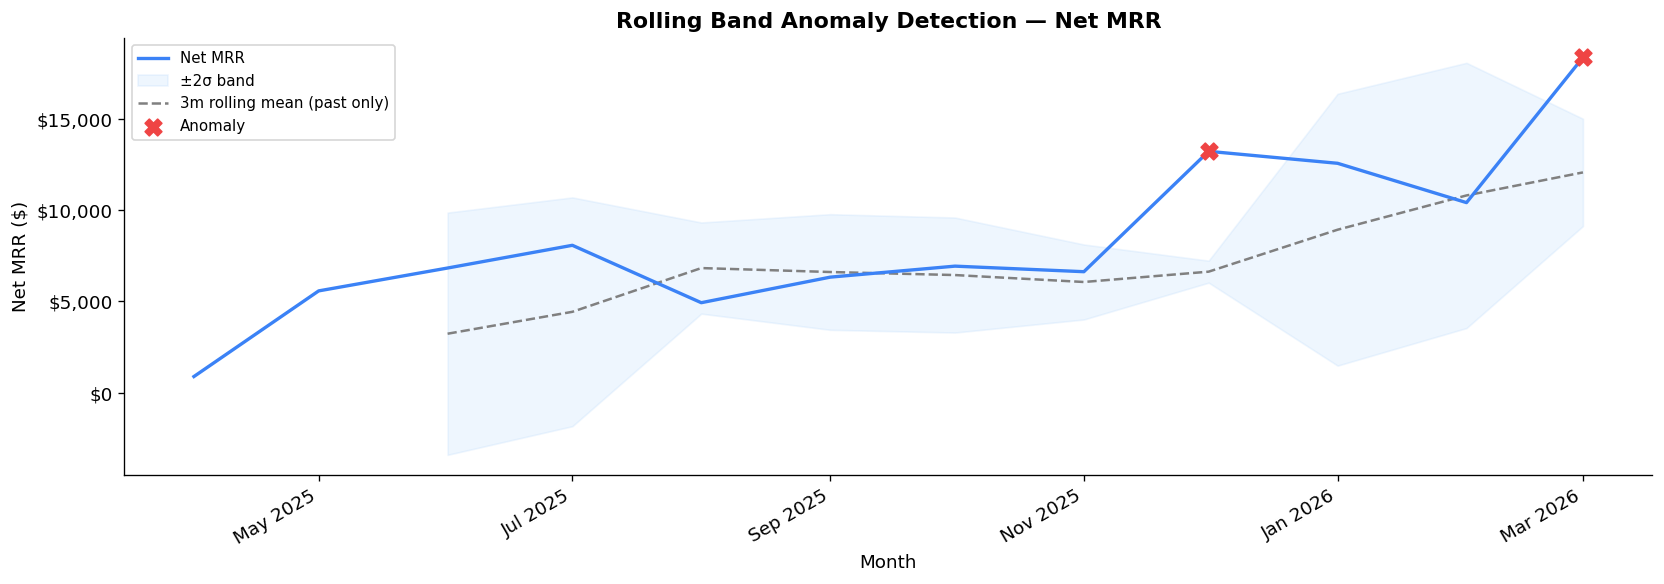

In [7]:
df_mrr = monthly_mrr.copy().sort_values('month').reset_index(drop=True)

WINDOW_MRR = 3
metric = 'net_mrr'  

# Use past-only window (important)
df_mrr['rolling_mean'] = df_mrr[metric].rolling(WINDOW_MRR, min_periods=2).mean().shift(1)
df_mrr['rolling_std']  = df_mrr[metric].rolling(WINDOW_MRR, min_periods=2).std().shift(1)

df_mrr['upper_band'] = df_mrr['rolling_mean'] + 2 * df_mrr['rolling_std']
df_mrr['lower_band'] = df_mrr['rolling_mean'] - 2 * df_mrr['rolling_std']

df_mrr['is_anomaly'] = (
    (df_mrr[metric] < df_mrr['lower_band']) |
    (df_mrr[metric] > df_mrr['upper_band'])
)

anomalies_mrr = df_mrr[df_mrr['is_anomaly']]

print(f"MRR anomalies: {len(anomalies_mrr)}")
if len(anomalies_mrr):
    print(anomalies_mrr[['month', metric]].to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_mrr['month'], df_mrr[metric],
        color=COLORS['normal'], lw=2, label='Net MRR', zorder=3)
ax.fill_between(df_mrr['month'], df_mrr['lower_band'], df_mrr['upper_band'],
                alpha=0.15, color=COLORS['band'], label='±2σ band')
ax.plot(df_mrr['month'], df_mrr['rolling_mean'],
        color='gray', linestyle='--', lw=1.5, label=f'{WINDOW_MRR}m rolling mean (past only)')
if len(anomalies_mrr):
    ax.scatter(anomalies_mrr['month'], anomalies_mrr[metric],
               color=COLORS['anomaly'], s=100, zorder=5, label='Anomaly', marker='X')
ax.set_title('Rolling Band Anomaly Detection — Net MRR', fontweight='bold')
ax.set_ylabel('Net MRR ($)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Importing plotly failed. Interactive plots will not work.
15:22:52 - cmdstanpy - INFO - Chain [1] start processing
15:22:54 - cmdstanpy - INFO - Chain [1] done processing


Anomalies (test): 0


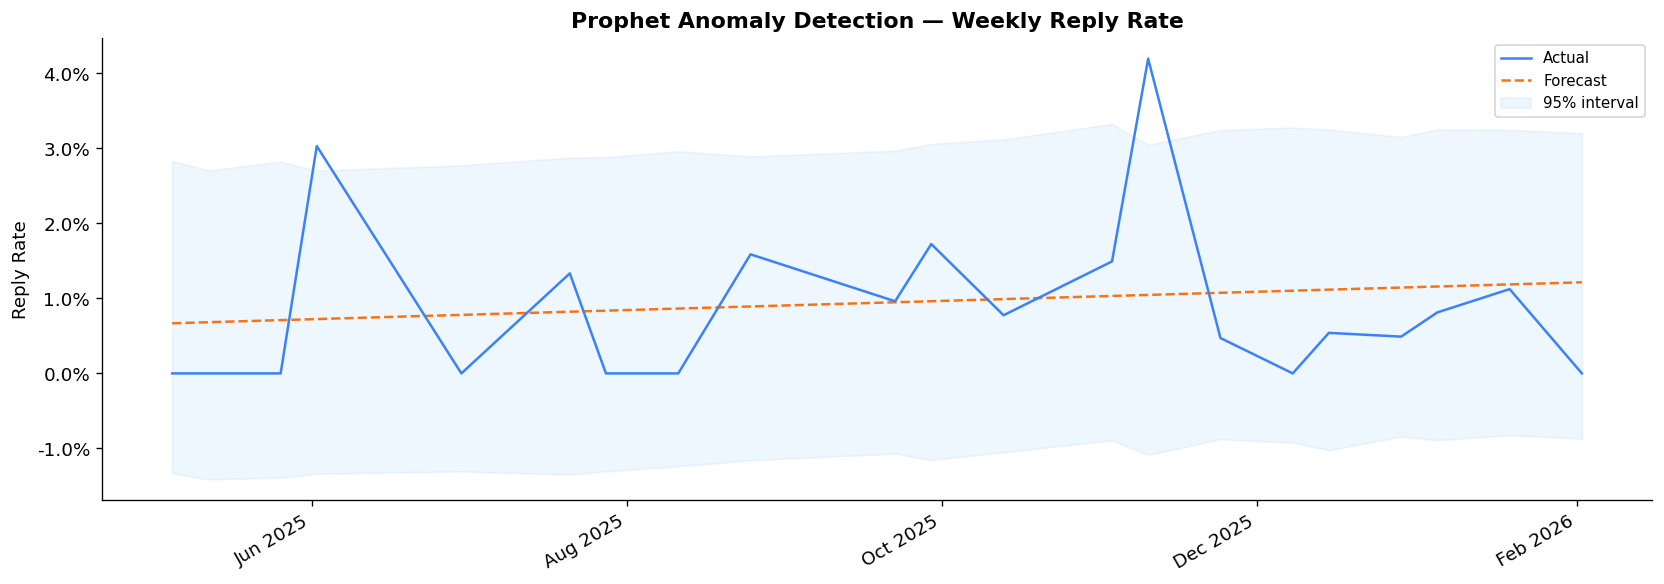

In [8]:
from prophet import Prophet

prophet_df = weekly_email[['week','reply_rate']].rename(
    columns={'week': 'ds', 'reply_rate': 'y'}
).copy()

# Train/test split
split_idx = int(len(prophet_df) * 0.8)
train_df  = prophet_df.iloc[:split_idx]

m = Prophet(
    interval_width=0.95,
    changepoint_prior_scale=0.05,
    weekly_seasonality=True
)

m.fit(train_df)

future = m.make_future_dataframe(
    periods=len(prophet_df) - len(train_df),
    freq='W-MON'   # important fix
)

forecast = m.predict(future)

results = prophet_df.merge(
    forecast[['ds','yhat','yhat_lower','yhat_upper']],
    on='ds'
)

results['is_anomaly'] = (
    (results['y'] < results['yhat_lower']) |
    (results['y'] > results['yhat_upper'])
)

results['pct_diff'] = (
    (results['y'] - results['yhat']) / results['yhat'] * 100
).round(1)

#  Evaluation
test_results = results.iloc[split_idx:]
anomalies_prophet = test_results[test_results['is_anomaly']]

print(f"Anomalies (test): {len(anomalies_prophet)}")

# Plot 
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(results['ds'], results['y'],
        color=COLORS['normal'], lw=1.5, label='Actual', zorder=3)

ax.plot(results['ds'], results['yhat'],
        color=COLORS['forecast'], lw=1.5, linestyle='--', label='Forecast')

ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.15, color=COLORS['band'], label='95% interval')

if len(anomalies_prophet):
    ax.scatter(anomalies_prophet['ds'], anomalies_prophet['y'],
               color=COLORS['anomaly'], s=90, zorder=5, label='Anomaly', marker='X')

ax.set_title('Prophet Anomaly Detection — Weekly Reply Rate', fontweight='bold')
ax.set_ylabel('Reply Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

 Simulated Drop
Week     : 2026-04-13
Change   : -15.0%
Z-score  : -1.41
Detected : NO 

Interpretation
Could be noise — monitor next weeks


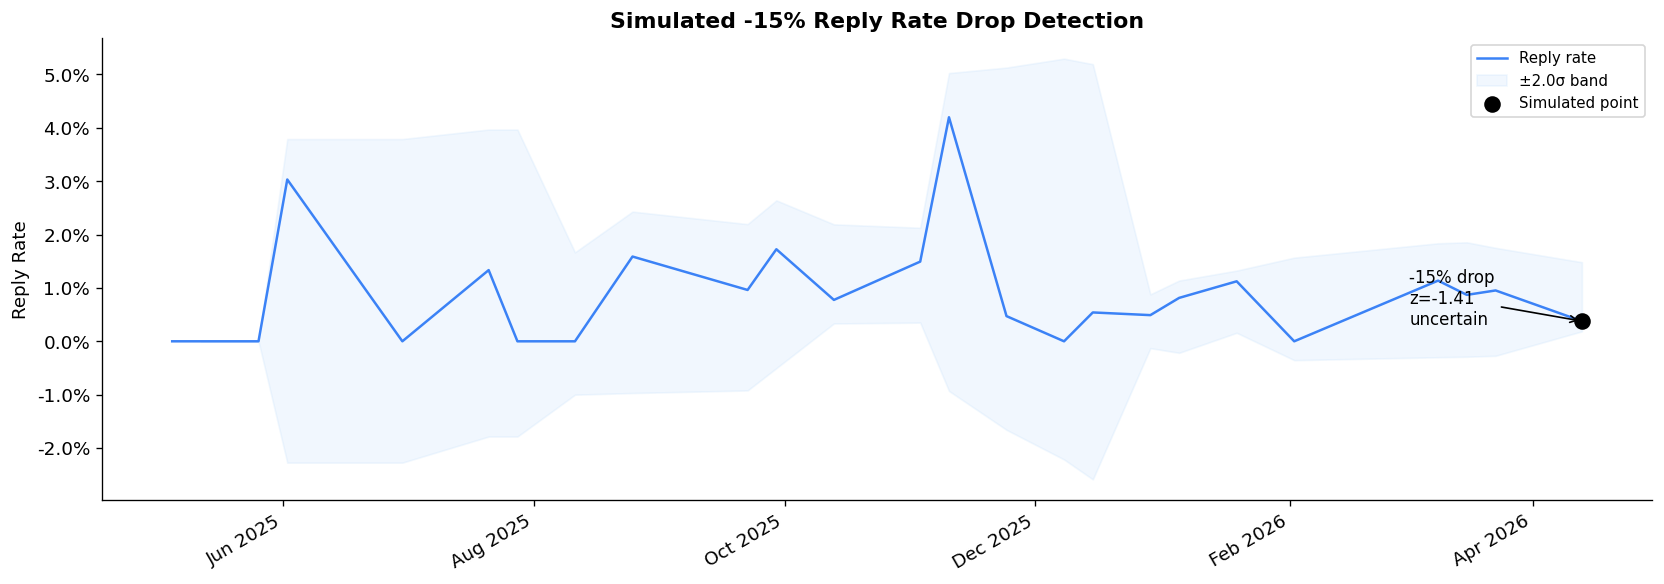

In [11]:
# anomaly: -15% reply rate drop

df_sim = df.copy()
last_idx  = df_sim.index[-1]

real_rate = df_sim.loc[last_idx, 'reply_rate']
dropped   = real_rate * 0.85
df_sim.loc[last_idx, 'reply_rate'] = dropped

# z-score 
df_sim['rolling_mean'] = df_sim['reply_rate'].rolling(WINDOW, min_periods=2).mean()
df_sim['rolling_std']  = df_sim['reply_rate'].rolling(WINDOW, min_periods=2).std()

df_sim['z_score'] = (
    (df_sim['reply_rate'] - df_sim['rolling_mean']) /
    df_sim['rolling_std'].replace(0, np.nan)
)

df_sim['is_anomaly'] = df_sim['z_score'].abs() > THRESHOLD

drop_row = df_sim.iloc[-1]

# Stats (approximate)
z = drop_row['z_score']
p_value = 2 * (1 - stats.norm.cdf(abs(z))) if pd.notna(z) else np.nan

#Summary
print(" Simulated Drop")
print(f"Week     : {drop_row['week'].date()}")
print(f"Change   : {(dropped - real_rate) / real_rate * 100:.1f}%")

if pd.notna(z):
    print(f"Z-score  : {z:.2f}")
    print(f"Detected : {'YES ' if drop_row['is_anomaly'] else 'NO '}")
else:
    print("Z-score  : N/A (low variance window)")
    print("Detected : NO ")

print("\nInterpretation")
if pd.notna(p_value) and p_value < 0.05:
    print("Signal likely real (not random noise)")
else:
    print("Could be noise — monitor next weeks")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_sim['week'], df_sim['reply_rate'],
        color=COLORS['normal'], lw=1.5, label='Reply rate', zorder=3)

ax.fill_between(
    df_sim['week'],
    df_sim['rolling_mean'] - THRESHOLD * df_sim['rolling_std'],
    df_sim['rolling_mean'] + THRESHOLD * df_sim['rolling_std'],
    alpha=0.12, color=COLORS['band'], label=f'±{THRESHOLD}σ band'
)

# Highlight anomaly point
if drop_row['is_anomaly']:
    ax.scatter(drop_row['week'], dropped,
               color=COLORS['anomaly'], s=120, zorder=5, marker='X',
               label=f'Anomaly (z={z:.2f})')
else:
    ax.scatter(drop_row['week'], dropped,
               color='black', s=80, zorder=5, label='Simulated point')

# Annotation
annot_text = (
    f"-15% drop\nz={z:.2f}\n"
    f"{'significant' if pd.notna(p_value) and p_value < 0.05 else 'uncertain'}"
    if pd.notna(z) else "-15% drop\ninsufficient variance"
)

ax.annotate(
    annot_text,
    xy     = (drop_row['week'], dropped),
    xytext = (drop_row['week'] - pd.Timedelta(weeks=6), dropped * 0.85),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
)

ax.set_title('Simulated -15% Reply Rate Drop Detection', fontweight='bold')
ax.set_ylabel('Reply Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()